In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

```markdown
## Consolidated Code

Below is all the code from the previous cells combined into a single executable cell.
```

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df=pd.read_csv('/content/covid_19_clean_complete.csv')

df.head()

df.rename(columns={'Province/State':'state','Country/Region':'country'},inplace=True)

df.info()

df['Date'].value_counts()

df['Date'].max()

top_date=df[df['Date']=='31-05-2020']

top_date.head(10)

top_date.groupby(['country'])[['Confirmed','Deaths','Recovered','Active']].sum().reset_index()

confirmed_case=df.groupby(['Date'])['Confirmed'].sum().reset_index()
confirmed_case

plt.figure(figsize=(20,5))
sns.lineplot(data=confirmed_case ,x='Date',y='Confirmed')
plt.xlabel('Date')
plt.ylabel('Confirmed Cases')
plt.title('Confirmed Cases')
plt.show()

death_case=df.groupby(['Date'])['Deaths'].sum().reset_index()
death_case

plt.figure(figsize=(20,5))
sns.lineplot(data=death_case ,x='Date',y='Deaths')
plt.xlabel('Date')
plt.ylabel('death ')
plt.title('death Cases')
plt.show()

Recovered_case=df.groupby(['Date'])['Recovered'].sum().reset_index()
Recovered_case

plt.figure(figsize=(20,5))
sns.lineplot(data=Recovered_case ,x='Date',y='Recovered')
plt.xlabel('Date')
plt.ylabel('Recovered ')
plt.title('Recovered Cases')
plt.show()

active_case=df.groupby(['Date'])['Active'].sum().reset_index()
active_case

plt.figure(figsize=(20,5))
sns.lineplot(data=active_case ,x='Date',y='Active')
plt.xlabel('Date')
plt.ylabel('Active ')
plt.title('Active Cases')
plt.show()

plt.figure(figsize=(20,5))
sns.pointplot(data=confirmed_case ,x='Date',y='Confirmed')
sns.pointplot(data=active_case ,x='Date',y='Active')
sns.pointplot(data=Recovered_case ,x='Date',y='Recovered')
sns.pointplot(data=death_case ,x='Date',y='Deaths')
plt.xlabel('Date')
plt.show()

noofcaesin_each_country=df.groupby(['country'])['Confirmed'].sum().reset_index()

noofcaesin_each_country=noofcaesin_each_country.sort_values('Confirmed',ascending=False)

noofcaesin_each_country.head(3)

# most affected country
#1. US
#2. Brazil
#3. Russia

US=df[df['country']=='US']

US

US=df.groupby(['Date'])[['Confirmed','Deaths','Recovered','Active']].sum().reset_index()
US

plt.figure(figsize=(20,5))
sns.pointplot(data=US ,x='Date',y='Confirmed')
sns.pointplot(data=US ,x='Date',y='Active')
sns.pointplot(data=US ,x='Date',y='Recovered')
sns.pointplot(data=US ,x='Date',y='Deaths')
plt.xlabel('Date')
plt.ylabel('cases')
plt.show()

Brazil=df[df['country']=='Brazil']

Brazil

Brazil=df.groupby(['Date'])[['Confirmed','Deaths','Recovered','Active']].sum().reset_index()
Brazil

plt.figure(figsize=(20,5))
sns.pointplot(data=Brazil ,x='Date',y='Confirmed')
sns.pointplot(data=Brazil ,x='Date',y='Active')
sns.pointplot(data=Brazil ,x='Date',y='Recovered')
sns.pointplot(data=Brazil ,x='Date',y='Deaths')
plt.xlabel('Date')
plt.ylabel('cases')
plt.show()

Russia=df[df['country']=='Russia']

Russia

Russia=df.groupby(['Date'])[['Confirmed','Deaths','Recovered','Active']].sum().reset_index()
Russia

plt.figure(figsize=(20,5))
sns.pointplot(data=Russia ,x='Date',y='Confirmed')
sns.pointplot(data=Russia ,x='Date',y='Active')
sns.pointplot(data=Russia ,x='Date',y='Recovered')
sns.pointplot(data=Russia ,x='Date',y='Deaths')
plt.xlabel('Date')
plt.ylabel('cases')
plt.show()

# MODEL BUILD

confirmed_cases=df.groupby(['Date']).sum()['Confirmed'].reset_index()
confirmed_cases.columns=['ds','y']
confirmed_cases['ds'] = pd.to_datetime(confirmed_cases['ds'], format='%d-%m-%Y')
confirmed_cases

from prophet import Prophet

Model=Prophet()

Model.fit(confirmed_cases)

# NOTE: The original notebook had a typo 'model' instead of 'Model'
# Correcting to use 'Model' as defined earlier.
future=Model.make_future_dataframe(periods=7)
forcasted=Model.predict(future)
forcasted

forcasted[['yhat_lower','yhat','yhat_upper']]

Model.plot(forcasted)
plt.show()

Recovered_case.columns=['ds','y']
Recovered_case['ds'] = pd.to_datetime(Recovered_case['ds'], format='%d-%m-%Y')
model_recovered=Prophet()
model_recovered.fit(Recovered_case)
future=model_recovered.make_future_dataframe(periods=7)
forcasted=model_recovered.predict(future)
forcasted

active_case.columns=['ds','y']
active_case['ds'] = pd.to_to_datetime(active_case['ds'], format='%d-%m-%Y') # Fix: pd.to_to_datetime should be pd.to_datetime
model_active=Prophet()
model_active.fit(active_case)
future=model_active.make_future_dataframe(periods=7)
forcasted=model_active.predict(future)
forcasted

death_case.columns=['ds','y']
death_case['ds'] = pd.to_datetime(death_case['ds'], format='%d-%m-%Y')
model_death=Prophet()
model_death.fit(death_case)
future=model_death.make_future_dataframe(periods=7)
forcasted=model_death.predict(future)
forcasted

import plotly

import plotly.express as px

world=df.groupby(['country'])[['Confirmed','Active','Deaths','Recovered']].sum().reset_index()
world

figure=px.choropleth(world,locations='country',locationmode='country names',color='Active',hover_name='country',range_color=[1,100000],color_continuous_scale='reds',title='World map for the Active cases')
figure.show()


In [ ]:
df=pd.read_csv('/content/covid_19_clean_complete.csv')

In [ ]:
df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,22-01-2020,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,22-01-2020,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,22-01-2020,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,22-01-2020,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,22-01-2020,0,0,0,0,Africa


In [ ]:
df.rename(columns={'Province/State':'state','Country/Region':'country'},inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   state       14664 non-null  object 
 1   country     49068 non-null  object 
 2   Lat         49068 non-null  float64
 3   Long        49068 non-null  float64
 4   Date        49068 non-null  object 
 5   Confirmed   49068 non-null  int64  
 6   Deaths      49068 non-null  int64  
 7   Recovered   49068 non-null  int64  
 8   Active      49068 non-null  int64  
 9   WHO Region  49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [ ]:
df['Date'].value_counts()

,count
Date,
22-01-2020,261
23-01-2020,261
24-01-2020,261
25-01-2020,261
26-01-2020,261
...,...
23-07-2020,261
24-07-2020,261
25-07-2020,261


In [ ]:
df['Date'].max()

'31-05-2020'

In [ ]:
top_date=df[df['Date']=='31-05-2020']

In [ ]:
top_date.head(10)

,state,country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
33930,NaN,Afghanistan,33.93911,67.709953,31-05-2020,15205,257,1328,13620,Eastern Mediterranean
33931,NaN,Albania,41.15330,20.168300,31-05-2020,1137,33,872,232,Europe
33932,NaN,Algeria,28.03390,1.659600,31-05-2020,9394,653,5748,2993,Africa
33933,NaN,Andorra,42.50630,1.521800,31-05-2020,764,51,694,19,Europe
33934,NaN,Angola,-11.20270,17.873900,31-05-2020,86,4,18,64,Africa
33935,NaN,Antigua and Barbuda,17.06080,-61.796400,31-05-2020,26,3,19,4,Americas
33936,NaN,Argentina,-38.41610,-63.616700,31-05-2020,16851,539,5336,10976,Americas
33937,NaN,Armenia,40.06910,45.038200,31-05-2020,9282,131,3386,5765,Europe
33938,Australian Capital Territory,Australia,-35.47350,149.012400,31-05-2020,107,3,104,0,Western Pacific
33939,New South Wales,Australia,-33.86880,151.209300,31-05-2020,3098,48,2685,365,Western Pacific


In [ ]:
top_date.groupby(['country'])[['Confirmed','Deaths','Recovered','Active']].sum().reset_index()

,country,Confirmed,Deaths,Recovered,Active
0,Afghanistan,15205,257,1328,13620
1,Albania,1137,33,872,232
2,Algeria,9394,653,5748,2993
3,Andorra,764,51,694,19
4,Angola,86,4,18,64
...,...,...,...,...,...
182,West Bank and Gaza,448,3,372,73
183,Western Sahara,9,1,6,2
184,Yemen,323,80,14,229
185,Zambia,1057,7,779,271


In [ ]:
confirmed_case=df.groupby(['Date'])['Confirmed'].sum().reset_index()
confirmed_case

,Date,Confirmed
0,01-02-2020,12038
1,01-03-2020,87690
2,01-04-2020,947569
3,01-05-2020,3355922
4,01-06-2020,6280725
...,...,...
183,30-05-2020,6077978
184,30-06-2020,10449697
185,31-01-2020,9927
186,31-03-2020,871355


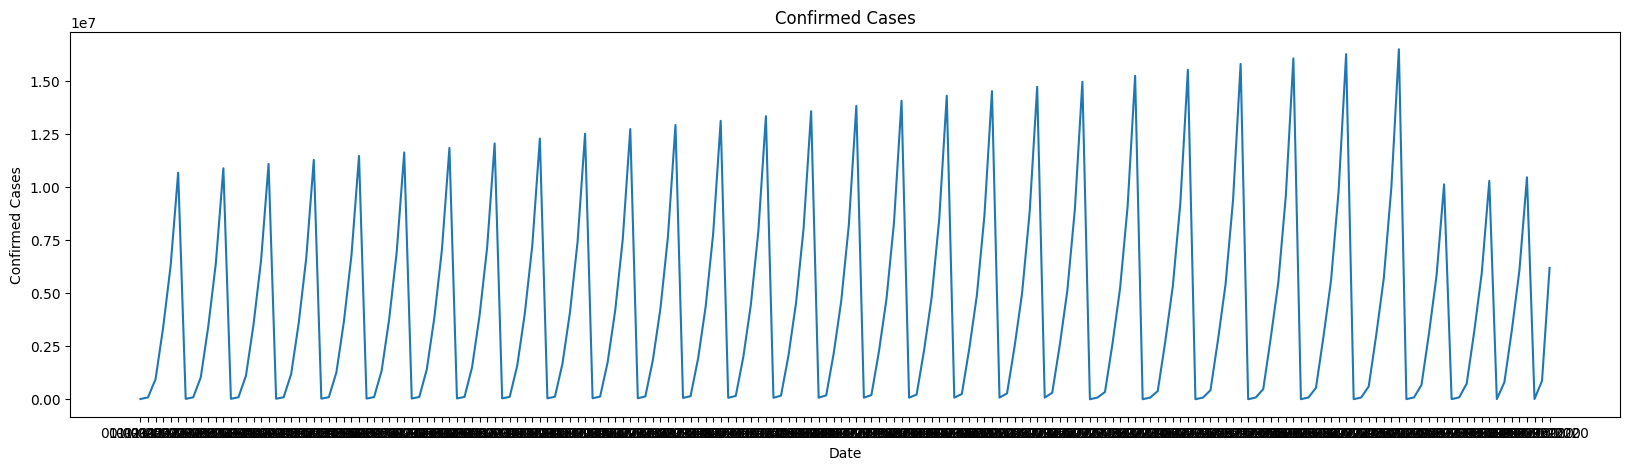

In [ ]:
plt.figure(figsize=(20,5))
sns.lineplot(data=confirmed_case ,x='Date',y='Confirmed')
plt.xlabel('Date')
plt.ylabel('Confirmed Cases')
plt.title('Confirmed Cases')
plt.show()

In [ ]:
death_case=df.groupby(['Date'])['Deaths'].sum().reset_index()
death_case

,Date,Deaths
0,01-02-2020,259
1,01-03-2020,2990
2,01-04-2020,50029
3,01-05-2020,239881
4,01-06-2020,376674
...,...,...
183,30-05-2020,370718
184,30-06-2020,511210
185,31-01-2020,213
186,31-03-2020,44478


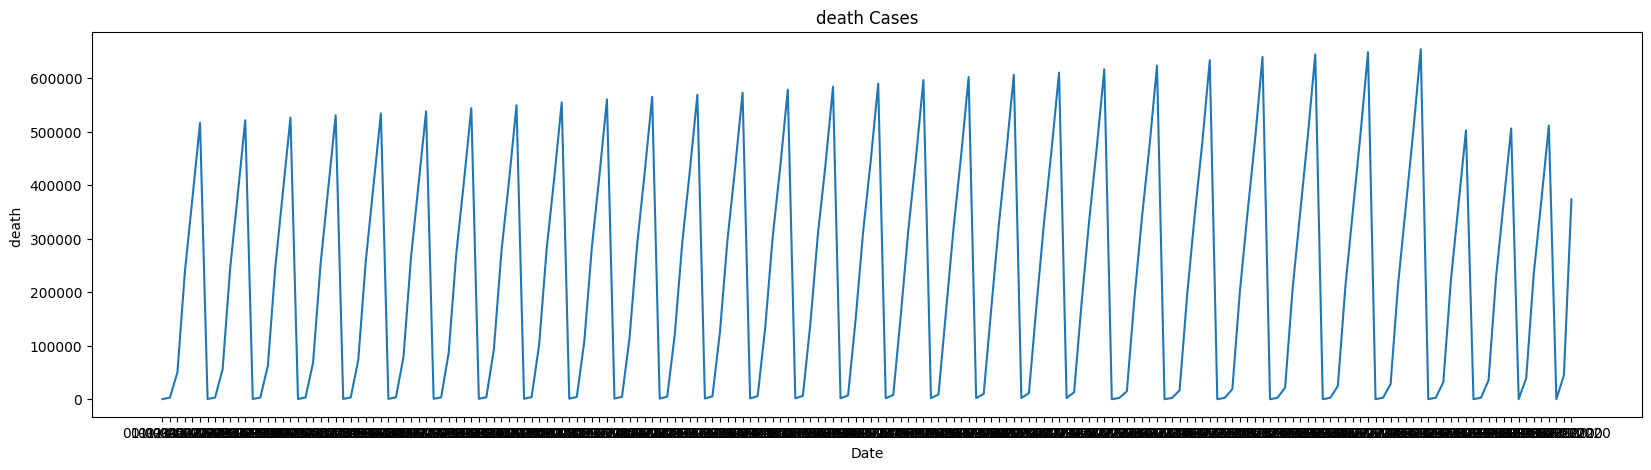

In [ ]:
plt.figure(figsize=(20,5))
sns.lineplot(data=death_case ,x='Date',y='Deaths')
plt.xlabel('Date')
plt.ylabel('death ')
plt.title('death Cases')
plt.show()

In [ ]:
Recovered_case=df.groupby(['Date'])['Recovered'].sum().reset_index()
Recovered_case

,Date,Recovered
0,01-02-2020,281
1,01-03-2020,41208
2,01-04-2020,189434
3,01-05-2020,1026501
4,01-06-2020,2639599
...,...,...
183,30-05-2020,2509981
184,30-06-2020,5281459
185,31-01-2020,219
186,31-03-2020,174074


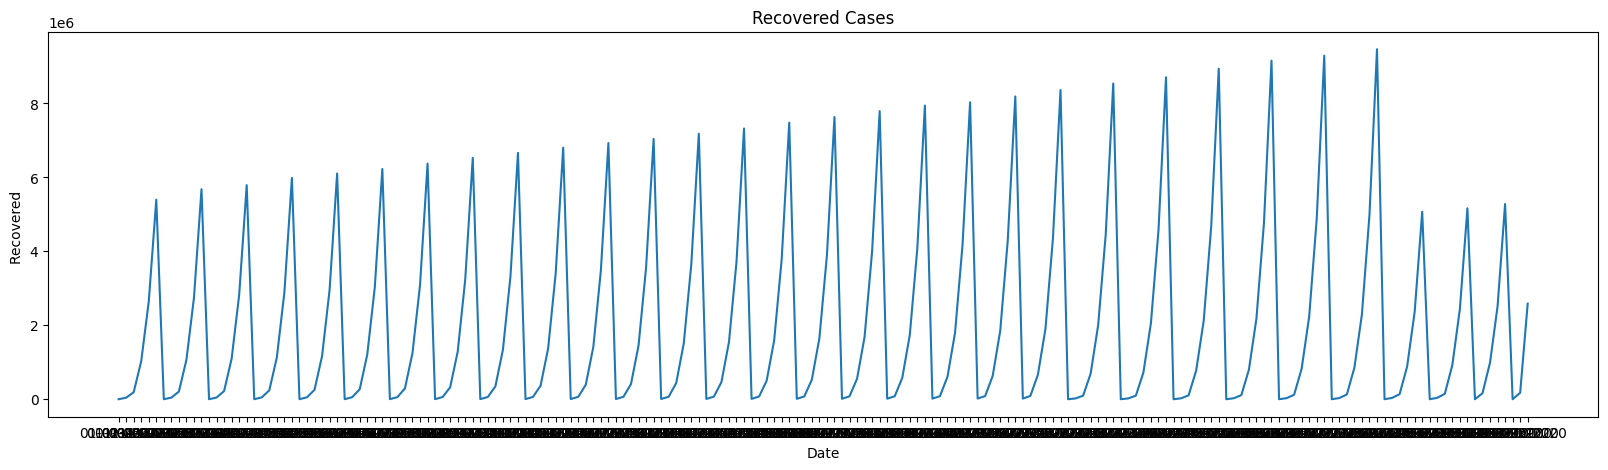

In [ ]:
plt.figure(figsize=(20,5))
sns.lineplot(data=Recovered_case ,x='Date',y='Recovered')
plt.xlabel('Date')
plt.ylabel('Recovered ')
plt.title('Recovered Cases')
plt.show()

In [ ]:
active_case=df.groupby(['Date'])['Active'].sum().reset_index()
active_case

,Date,Active
0,01-02-2020,11498
1,01-03-2020,43492
2,01-04-2020,708106
3,01-05-2020,2089540
4,01-06-2020,3264452
...,...,...
183,30-05-2020,3197279
184,30-06-2020,4657028
185,31-01-2020,9495
186,31-03-2020,652803


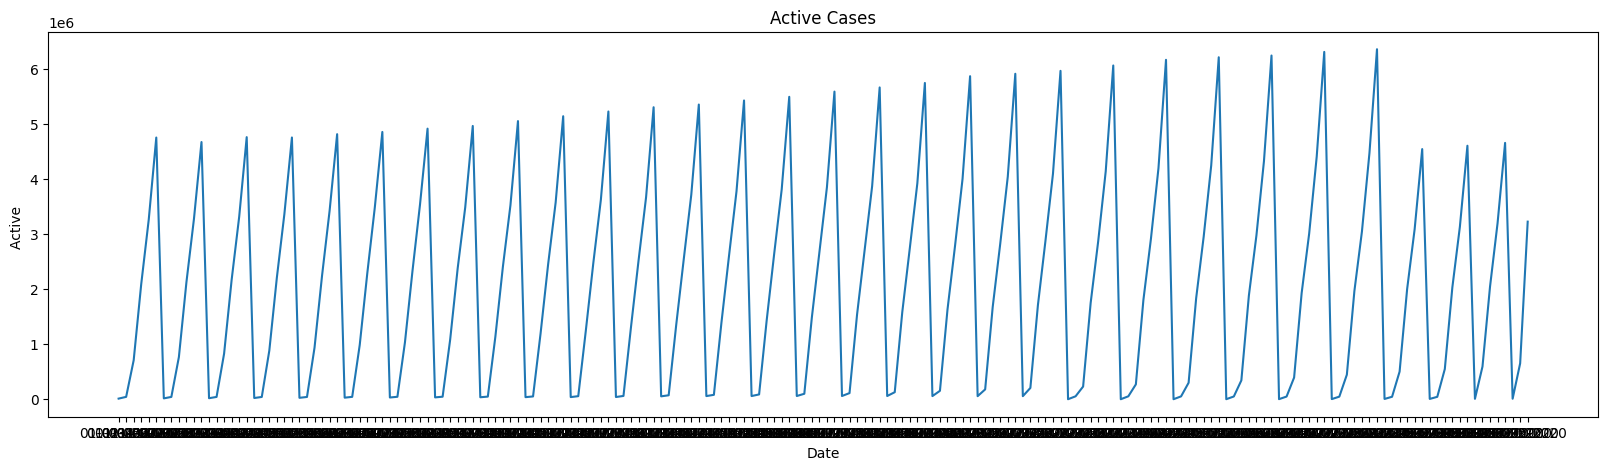

In [ ]:
plt.figure(figsize=(20,5))
sns.lineplot(data=active_case ,x='Date',y='Active')
plt.xlabel('Date')
plt.ylabel('Active ')
plt.title('Active Cases')
plt.show()

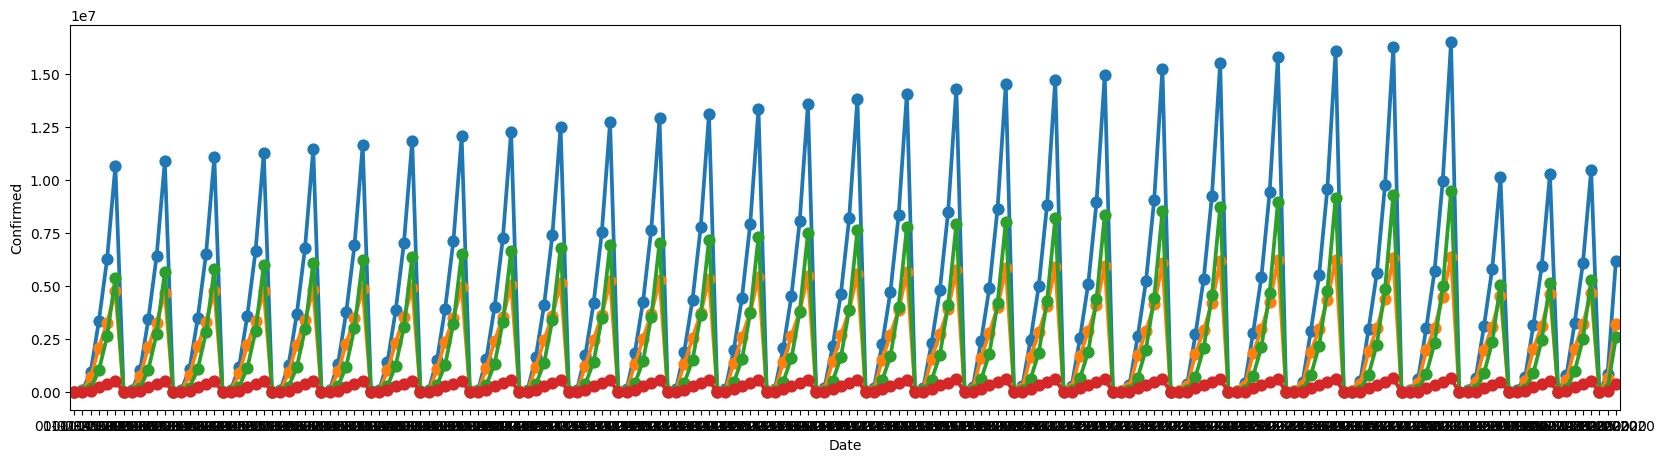

In [ ]:
plt.figure(figsize=(20,5))
sns.pointplot(data=confirmed_case ,x='Date',y='Confirmed')
sns.pointplot(data=active_case ,x='Date',y='Active')
sns.pointplot(data=Recovered_case ,x='Date',y='Recovered')
sns.pointplot(data=death_case ,x='Date',y='Deaths')
plt.xlabel('Date')
plt.show()

In [ ]:
noofcaesin_each_country=df.groupby(['country'])['Confirmed'].sum().reset_index()

In [ ]:
noofcaesin_each_country=noofcaesin_each_country.sort_values('Confirmed',ascending=False)

In [ ]:
noofcaesin_each_country.head(3)

,country,Confirmed
173,US,224345948
23,Brazil,89524967
138,Russia,45408411


In [ ]:
# most affected country
#1. US
#2. Brazil
#3. Russia

In [ ]:
US=df[df['country']=='US']

In [ ]:
US

,state,country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
223,NaN,US,40.0,-100.0,22-01-2020,1,0,0,1,Americas
484,NaN,US,40.0,-100.0,23-01-2020,1,0,0,1,Americas
745,NaN,US,40.0,-100.0,24-01-2020,2,0,0,2,Americas
1006,NaN,US,40.0,-100.0,25-01-2020,2,0,0,2,Americas
1267,NaN,US,40.0,-100.0,26-01-2020,5,0,0,5,Americas
...,...,...,...,...,...,...,...,...,...,...
47986,NaN,US,40.0,-100.0,23-07-2020,4038816,144430,1233269,2661117,Americas
48247,NaN,US,40.0,-100.0,24-07-2020,4112531,145560,1261624,2705347,Americas
48508,NaN,US,40.0,-100.0,25-07-2020,4178970,146465,1279414,2753091,Americas
48769,NaN,US,40.0,-100.0,26-07-2020,4233923,146935,1297863,2789125,Americas


In [ ]:
US=df.groupby(['Date'])[['Confirmed','Deaths','Recovered','Active']].sum().reset_index()
US

,Date,Confirmed,Deaths,Recovered,Active
0,01-02-2020,12038,259,281,11498
1,01-03-2020,87690,2990,41208,43492
2,01-04-2020,947569,50029,189434,708106
3,01-05-2020,3355922,239881,1026501,2089540
4,01-06-2020,6280725,376674,2639599,3264452
...,...,...,...,...,...
183,30-05-2020,6077978,370718,2509981,3197279
184,30-06-2020,10449697,511210,5281459,4657028
185,31-01-2020,9927,213,219,9495
186,31-03-2020,871355,44478,174074,652803


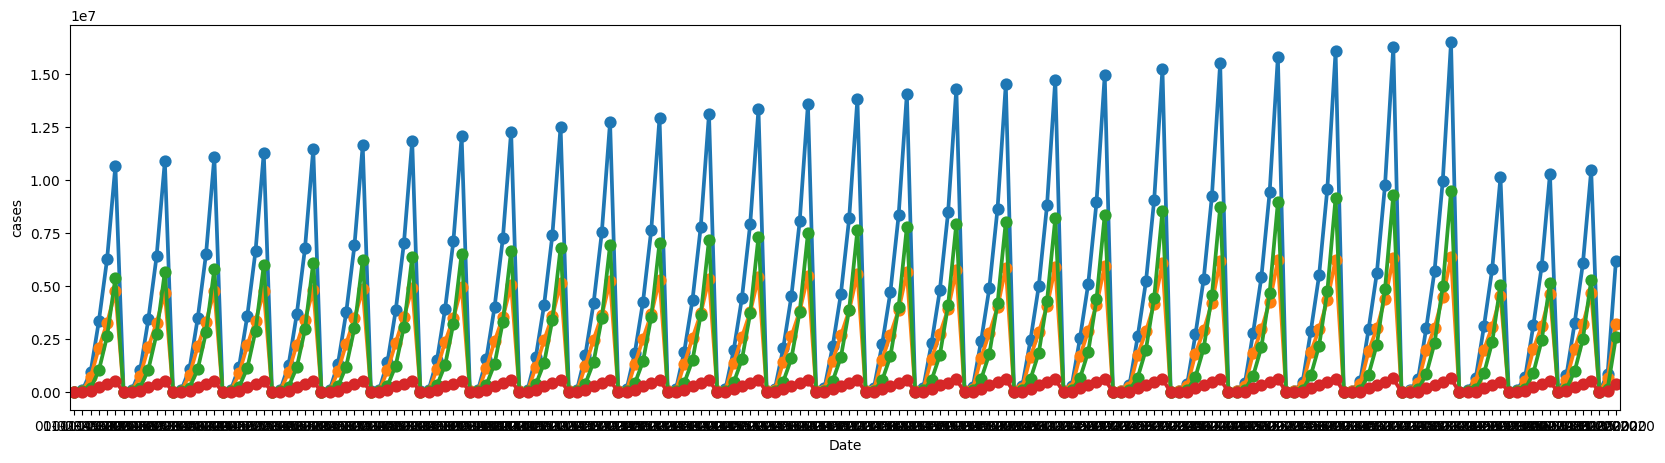

In [ ]:
plt.figure(figsize=(20,5))
sns.pointplot(data=US ,x='Date',y='Confirmed')
sns.pointplot(data=US ,x='Date',y='Active')
sns.pointplot(data=US ,x='Date',y='Recovered')
sns.pointplot(data=US ,x='Date',y='Deaths')
plt.xlabel('Date')
plt.ylabel('cases')
plt.show()

In [ ]:
Brazil=df[df['country']=='Brazil']

In [ ]:
Brazil

,state,country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
28,NaN,Brazil,-14.235,-51.9253,22-01-2020,0,0,0,0,Americas
289,NaN,Brazil,-14.235,-51.9253,23-01-2020,0,0,0,0,Americas
550,NaN,Brazil,-14.235,-51.9253,24-01-2020,0,0,0,0,Americas
811,NaN,Brazil,-14.235,-51.9253,25-01-2020,0,0,0,0,Americas
1072,NaN,Brazil,-14.235,-51.9253,26-01-2020,0,0,0,0,Americas
...,...,...,...,...,...,...,...,...,...,...
47791,NaN,Brazil,-14.235,-51.9253,23-07-2020,2287475,84082,1620313,583080,Americas
48052,NaN,Brazil,-14.235,-51.9253,24-07-2020,2343366,85238,1693214,564914,Americas
48313,NaN,Brazil,-14.235,-51.9253,25-07-2020,2394513,86449,1785359,522705,Americas
48574,NaN,Brazil,-14.235,-51.9253,26-07-2020,2419091,87004,1812913,519174,Americas


In [ ]:
Brazil=df.groupby(['Date'])[['Confirmed','Deaths','Recovered','Active']].sum().reset_index()
Brazil

,Date,Confirmed,Deaths,Recovered,Active
0,01-02-2020,12038,259,281,11498
1,01-03-2020,87690,2990,41208,43492
2,01-04-2020,947569,50029,189434,708106
3,01-05-2020,3355922,239881,1026501,2089540
4,01-06-2020,6280725,376674,2639599,3264452
...,...,...,...,...,...
183,30-05-2020,6077978,370718,2509981,3197279
184,30-06-2020,10449697,511210,5281459,4657028
185,31-01-2020,9927,213,219,9495
186,31-03-2020,871355,44478,174074,652803


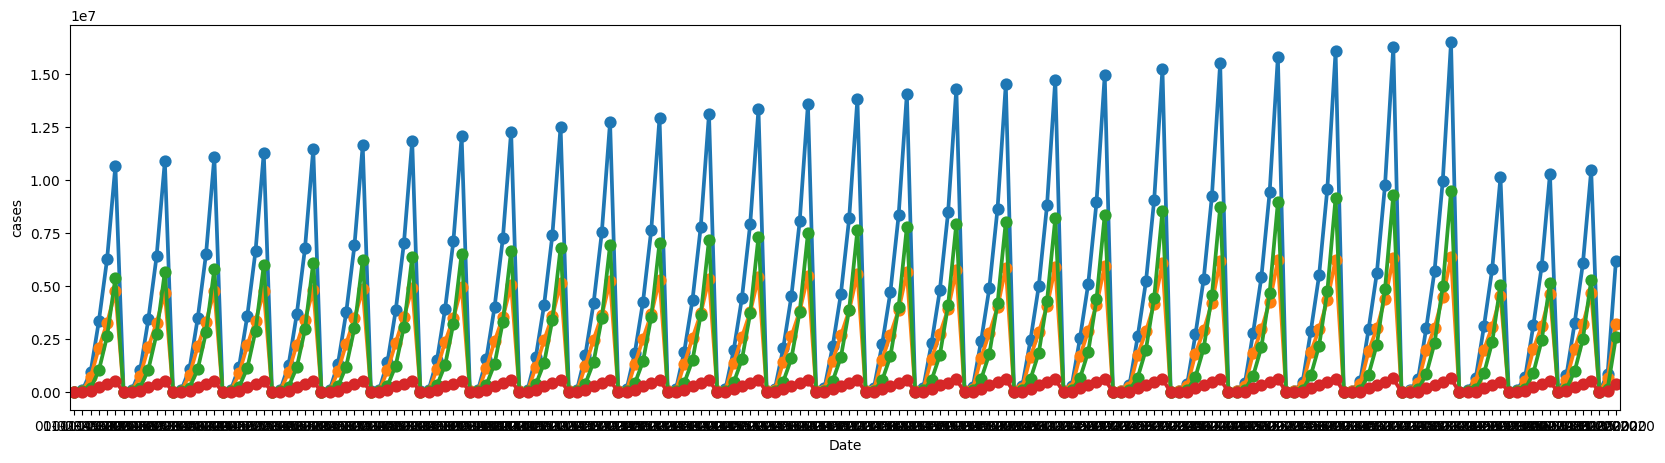

In [ ]:
plt.figure(figsize=(20,5))
sns.pointplot(data=Brazil ,x='Date',y='Confirmed')
sns.pointplot(data=Brazil ,x='Date',y='Active')
sns.pointplot(data=Brazil ,x='Date',y='Recovered')
sns.pointplot(data=Brazil ,x='Date',y='Deaths')
plt.xlabel('Date')
plt.ylabel('cases')
plt.show()

In [ ]:
Russia=df[df['country']=='Russia']

In [ ]:
Russia

,state,country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
185,NaN,Russia,61.52401,105.318756,22-01-2020,0,0,0,0,Europe
446,NaN,Russia,61.52401,105.318756,23-01-2020,0,0,0,0,Europe
707,NaN,Russia,61.52401,105.318756,24-01-2020,0,0,0,0,Europe
968,NaN,Russia,61.52401,105.318756,25-01-2020,0,0,0,0,Europe
1229,NaN,Russia,61.52401,105.318756,26-01-2020,0,0,0,0,Europe
...,...,...,...,...,...,...,...,...,...,...
47948,NaN,Russia,61.52401,105.318756,23-07-2020,793720,12873,579295,201552,Europe
48209,NaN,Russia,61.52401,105.318756,24-07-2020,799499,13026,587728,198745,Europe
48470,NaN,Russia,61.52401,105.318756,25-07-2020,805332,13172,596064,196096,Europe
48731,NaN,Russia,61.52401,105.318756,26-07-2020,811073,13249,599172,198652,Europe


In [ ]:
Russia=df.groupby(['Date'])[['Confirmed','Deaths','Recovered','Active']].sum().reset_index()
Russia

,Date,Confirmed,Deaths,Recovered,Active
0,01-02-2020,12038,259,281,11498
1,01-03-2020,87690,2990,41208,43492
2,01-04-2020,947569,50029,189434,708106
3,01-05-2020,3355922,239881,1026501,2089540
4,01-06-2020,6280725,376674,2639599,3264452
...,...,...,...,...,...
183,30-05-2020,6077978,370718,2509981,3197279
184,30-06-2020,10449697,511210,5281459,4657028
185,31-01-2020,9927,213,219,9495
186,31-03-2020,871355,44478,174074,652803


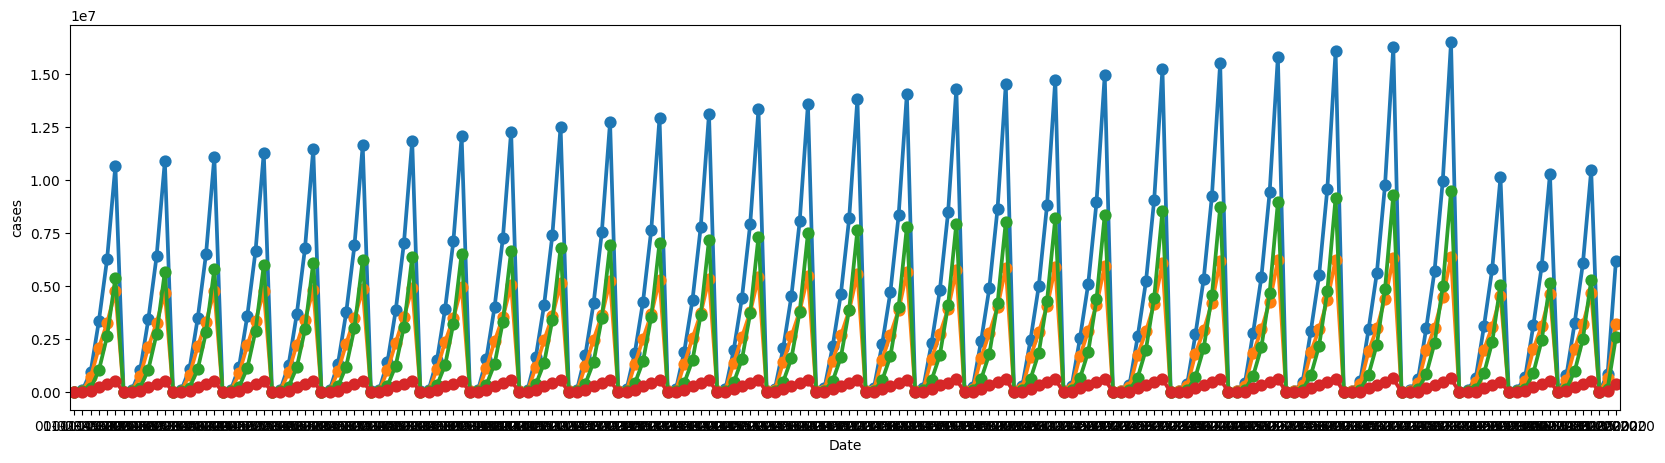

In [ ]:
plt.figure(figsize=(20,5))
sns.pointplot(data=Russia ,x='Date',y='Confirmed')
sns.pointplot(data=Russia ,x='Date',y='Active')
sns.pointplot(data=Russia ,x='Date',y='Recovered')
sns.pointplot(data=Russia ,x='Date',y='Deaths')
plt.xlabel('Date')
plt.ylabel('cases')
plt.show()

MODEL BUILD

In [ ]:
confirmed_cases=df.groupby(['Date']).sum()['Confirmed'].reset_index()
confirmed_cases.columns=['ds','y']
confirmed_cases['ds'] = pd.to_datetime(confirmed_cases['ds'], format='%d-%m-%Y')
confirmed_cases

,ds,y
0,2020-02-01,12038
1,2020-03-01,87690
2,2020-04-01,947569
3,2020-05-01,3355922
4,2020-06-01,6280725
...,...,...
183,2020-05-30,6077978
184,2020-06-30,10449697
185,2020-01-31,9927
186,2020-03-31,871355


In [ ]:
from prophet import Prophet

In [ ]:
Model=Prophet()

In [ ]:
Model.fit(confirmed_cases)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
future=model.make_future_dataframe(periods=7)
forcasted=model.predict(future)
forcasted

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-22,-9.613288e+03,-1.254118e+05,7.892065e+04,-9.613288e+03,-9.613288e+03,-11063.558307,-11063.558307,-11063.558307,-11063.558307,-11063.558307,-11063.558307,0.0,0.0,0.0,-2.067685e+04
1,2020-01-23,-6.933409e+03,-1.144556e+05,9.681596e+04,-6.933409e+03,-6.933409e+03,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,0.0,0.0,0.0,-8.050953e+03
2,2020-01-24,-4.253530e+03,-9.825792e+04,1.096605e+05,-4.253530e+03,-4.253530e+03,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,0.0,0.0,0.0,5.827449e+03
3,2020-01-25,-1.573651e+03,-9.616817e+04,1.171287e+05,-1.573651e+03,-1.573651e+03,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,0.0,0.0,0.0,1.217668e+04
4,2020-01-26,1.106228e+03,-9.830001e+04,1.140020e+05,1.106228e+03,1.106228e+03,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,0.0,0.0,0.0,8.405020e+03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,2020-07-30,1.674503e+07,1.664799e+07,1.684725e+07,1.674056e+07,1.674933e+07,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,0.0,0.0,0.0,1.674392e+07
191,2020-07-31,1.694902e+07,1.685500e+07,1.706931e+07,1.693855e+07,1.695870e+07,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,0.0,0.0,0.0,1.695911e+07
192,2020-08-01,1.715301e+07,1.705876e+07,1.727321e+07,1.713551e+07,1.716962e+07,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,0.0,0.0,0.0,1.716677e+07
193,2020-08-02,1.735701e+07,1.724687e+07,1.748681e+07,1.733082e+07,1.738307e+07,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,0.0,0.0,0.0,1.736430e+07


In [ ]:
forcasted[['yhat_lower','yhat','yhat_upper']]

,yhat_lower,yhat,yhat_upper
0,-1.254118e+05,-2.067685e+04,7.892065e+04
1,-1.144556e+05,-8.050953e+03,9.681596e+04
2,-9.825792e+04,5.827449e+03,1.096605e+05
3,-9.616817e+04,1.217668e+04,1.171287e+05
4,-9.830001e+04,8.405020e+03,1.140020e+05
...,...,...,...
190,1.664799e+07,1.674392e+07,1.684725e+07
191,1.685500e+07,1.695911e+07,1.706931e+07
192,1.705876e+07,1.716677e+07,1.727321e+07
193,1.724687e+07,1.736430e+07,1.748681e+07


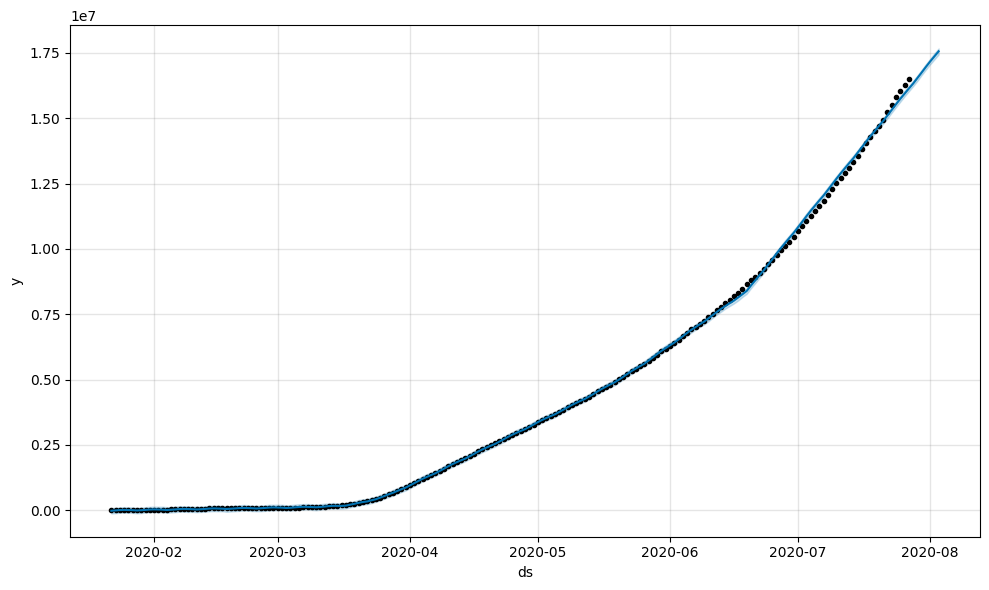

In [ ]:
model.plot(forcasted)
plt.show()

In [ ]:
Recovered_case.columns=['ds','y']
Recovered_case['ds'] = pd.to_datetime(Recovered_case['ds'], format='%d-%m-%Y')
model_recovered=Prophet()
model_recovered.fit(Recovered_case)
future=model_recovered.make_future_dataframe(periods=7)
forcasted=model_recovered.predict(future)
forcasted

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-22,-1.360144e+04,-1.023509e+05,6.154769e+04,-1.360144e+04,-1.360144e+04,-4840.633687,-4840.633687,-4840.633687,-4840.633687,-4840.633687,-4840.633687,0.0,0.0,0.0,-1.844208e+04
1,2020-01-23,-1.243662e+04,-8.979233e+04,6.665410e+04,-1.243662e+04,-1.243662e+04,1254.797967,1254.797967,1254.797967,1254.797967,1254.797967,1254.797967,0.0,0.0,0.0,-1.118182e+04
2,2020-01-24,-1.127180e+04,-7.656851e+04,7.296931e+04,-1.127180e+04,-1.127180e+04,6096.150124,6096.150124,6096.150124,6096.150124,6096.150124,6096.150124,0.0,0.0,0.0,-5.175647e+03
3,2020-01-25,-1.010697e+04,-8.008759e+04,7.745146e+04,-1.010697e+04,-1.010697e+04,9699.442818,9699.442818,9699.442818,9699.442818,9699.442818,9699.442818,0.0,0.0,0.0,-4.075311e+02
4,2020-01-26,-8.942151e+03,-8.575599e+04,6.687207e+04,-8.942151e+03,-8.942151e+03,-883.479296,-883.479296,-883.479296,-883.479296,-883.479296,-883.479296,0.0,0.0,0.0,-9.825630e+03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,2020-07-30,9.594538e+06,9.514074e+06,9.679313e+06,9.589851e+06,9.597784e+06,1254.797967,1254.797967,1254.797967,1254.797967,1254.797967,1254.797967,0.0,0.0,0.0,9.595793e+06
191,2020-07-31,9.731096e+06,9.654683e+06,9.818355e+06,9.722713e+06,9.738949e+06,6096.150124,6096.150124,6096.150124,6096.150124,6096.150124,6096.150124,0.0,0.0,0.0,9.737193e+06
192,2020-08-01,9.867654e+06,9.795355e+06,9.954385e+06,9.854162e+06,9.880648e+06,9699.442818,9699.442818,9699.442818,9699.442818,9699.442818,9699.442818,0.0,0.0,0.0,9.877354e+06
193,2020-08-02,1.000421e+07,9.919634e+06,1.008692e+07,9.984530e+06,1.002367e+07,-883.479296,-883.479296,-883.479296,-883.479296,-883.479296,-883.479296,0.0,0.0,0.0,1.000333e+07


In [ ]:
active_case.columns=['ds','y']
active_case['ds'] = pd.to_datetime(active_case['ds'], format='%d-%m-%Y')
model_active=Prophet()
model_active.fit(active_case)
future=model_active.make_future_dataframe(periods=7)
forcasted=model_active.predict(future)
forcasted

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-22,-5.051891e+02,-5.256396e+04,3.715832e+04,-5.051891e+02,-5.051891e+02,-5734.815309,-5734.815309,-5734.815309,-5734.815309,-5734.815309,-5734.815309,0.0,0.0,0.0,-6.240004e+03
1,2020-01-23,1.357197e+03,-4.730859e+04,4.397442e+04,1.357197e+03,1.357197e+03,-2543.415441,-2543.415441,-2543.415441,-2543.415441,-2543.415441,-2543.415441,0.0,0.0,0.0,-1.186218e+03
2,2020-01-24,3.219584e+03,-3.940479e+04,5.131905e+04,3.219584e+03,3.219584e+03,3230.785517,3230.785517,3230.785517,3230.785517,3230.785517,3230.785517,0.0,0.0,0.0,6.450369e+03
3,2020-01-25,5.081970e+03,-3.946321e+04,5.106917e+04,5.081970e+03,5.081970e+03,3128.006715,3128.006715,3128.006715,3128.006715,3128.006715,3128.006715,0.0,0.0,0.0,8.209977e+03
4,2020-01-26,6.944356e+03,-2.830204e+04,5.801753e+04,6.944356e+03,6.944356e+03,8151.913171,8151.913171,8151.913171,8151.913171,8151.913171,8151.913171,0.0,0.0,0.0,1.509627e+04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,2020-07-30,6.483822e+06,6.431800e+06,6.526223e+06,6.480326e+06,6.486104e+06,-2543.415441,-2543.415441,-2543.415441,-2543.415441,-2543.415441,-2543.415441,0.0,0.0,0.0,6.481279e+06
191,2020-07-31,6.546090e+06,6.500852e+06,6.592971e+06,6.538211e+06,6.550761e+06,3230.785517,3230.785517,3230.785517,3230.785517,3230.785517,3230.785517,0.0,0.0,0.0,6.549320e+06
192,2020-08-01,6.608357e+06,6.564595e+06,6.661861e+06,6.596853e+06,6.617312e+06,3128.006715,3128.006715,3128.006715,3128.006715,3128.006715,3128.006715,0.0,0.0,0.0,6.611485e+06
193,2020-08-02,6.670624e+06,6.625512e+06,6.726782e+06,6.655175e+06,6.684017e+06,8151.913171,8151.913171,8151.913171,8151.913171,8151.913171,8151.913171,0.0,0.0,0.0,6.678776e+06


In [ ]:
death_case.columns=['ds','y']
death_case['ds'] = pd.to_datetime(death_case['ds'], format='%d-%m-%Y')
model_death=Prophet()
model_death.fit(death_case)
future=model_death.make_future_dataframe(periods=7)
forcasted=model_death.predict(future)
forcasted

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-22,-522.113185,-2610.757447,1255.913445,-522.113185,-522.113185,-191.187755,-191.187755,-191.187755,-191.187755,-191.187755,-191.187755,0.0,0.0,0.0,-713.300939
1,2020-01-23,-432.419342,-1902.508026,1901.539031,-432.419342,-432.419342,388.672065,388.672065,388.672065,388.672065,388.672065,388.672065,0.0,0.0,0.0,-43.747277
2,2020-01-24,-342.725499,-1431.754888,2596.642523,-342.725499,-342.725499,874.264079,874.264079,874.264079,874.264079,874.264079,874.264079,0.0,0.0,0.0,531.538580
3,2020-01-25,-253.031656,-1545.078839,2413.139846,-253.031656,-253.031656,726.889465,726.889465,726.889465,726.889465,726.889465,726.889465,0.0,0.0,0.0,473.857809
4,2020-01-26,-163.337813,-2311.083532,1614.567656,-163.337813,-163.337813,-165.600459,-165.600459,-165.600459,-165.600459,-165.600459,-165.600459,0.0,0.0,0.0,-328.938272
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,2020-07-30,663102.734264,661373.992939,665641.785726,662855.094703,663396.583005,388.672065,388.672065,388.672065,388.672065,388.672065,388.672065,0.0,0.0,0.0,663491.406328
191,2020-07-31,668132.143204,666822.139442,671048.530914,667592.929002,668814.043358,874.264079,874.264079,874.264079,874.264079,874.264079,874.264079,0.0,0.0,0.0,669006.407283
192,2020-08-01,673161.552144,671452.805685,676201.594456,672244.850138,674222.548196,726.889465,726.889465,726.889465,726.889465,726.889465,726.889465,0.0,0.0,0.0,673888.441609
193,2020-08-02,678190.961084,675734.833456,680489.876783,676860.517411,679646.432186,-165.600459,-165.600459,-165.600459,-165.600459,-165.600459,-165.600459,0.0,0.0,0.0,678025.360624


In [ ]:
import plotly

In [ ]:
import plotly.express as px

In [ ]:
world=df.groupby(['country'])[['Confirmed','Active','Deaths','Recovered']].sum().reset_index()
world

,country,Confirmed,Active,Deaths,Recovered
0,Afghanistan,1936390,1089052,49098,798240
1,Albania,196702,72117,5708,118877
2,Algeria,1179755,345886,77972,755897
3,Andorra,94404,19907,5423,69074
4,Angola,22662,15011,1078,6573
...,...,...,...,...,...
182,West Bank and Gaza,233461,170967,1370,61124
183,Western Sahara,901,190,63,648
184,Yemen,67180,25694,17707,23779
185,Zambia,129421,43167,2643,83611


In [ ]:
figure=px.choropleth(world,locations='country',locationmode='country names',color='Active',hover_name='country',range_color=[1,100000],color_continuous_scale='reds',title='World map for the Active cases')
figure.show()